# Phase 10 — SC25 / SC26 Live Monitoring Tool

**Goal:** A lightweight, re-runnable monitor that tracks Solar Cycle 25's decline phase using the
latest monthly SSN data, projects an expected window for SC25's end / SC26's onset based on
historical decay/cycle-length statistics, and re-runs the **Phase 7 v2 running model**
(the project's best-known model — see Phases 7-9) to confirm continued post-peak detection.

**Why this phase:** Phases 6, 8b, and 9 each tried adding new features (polar field, geomagnetic
`aa` precursors, TDA peak-persistence) to the static and running models and found **no reliable
improvement** at N=24 cycles — the project has hit diminishing returns on feature engineering.
Rather than chase another feature, Phase 10 turns the existing best model (Phase 7 v2, unmodified)
into an operational tool: re-run it monthly as new SILSO data arrives to track SC25's tail end
and flag SC26's eventual minimum.

**How to refresh this notebook each month:**
1. Download the latest monthly total sunspot number file from SILSO
   (`SN_m_tot_V2.0.csv`, https://www.sidc.be/SILSO/datafiles) and replace
   `../data/SN_m_tot_V2.0.csv`.
2. Re-run all cells (Setup -> Status -> Projection -> Model -> SC26 Detector -> Report).
3. Read the **Monthly Status Report** at the end — it summarizes everything in one block.

**Sandbox note:** `scikit-learn` is not installed here. The Setup, Status, Projection, SC26
Detector, and Report cells use only NumPy/Pandas and are executed below with real outputs. The
Phase 7v2 model cell is complete and ready to run in your own environment with `scikit-learn`
installed.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor

DATA_DIR  = Path('../data')
PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)

cycle_db = pd.read_csv(DATA_DIR / 'Cycle_Database_completed.csv')
cycle_db['Start_Date'] = pd.to_datetime(cycle_db['Start_Date'])
cycle_db['Peak_Date']  = pd.to_datetime(cycle_db['Peak_Date'])
cycle_db['End_Date']   = pd.to_datetime(cycle_db['End_Date'])

sn_raw = pd.read_csv(DATA_DIR / 'SN_m_tot_V2.0.csv', sep=';', header=None,
                      names=['Year','Month','FracYear','SN','StdDev','Nobs','Definitive'])
sn_raw = sn_raw[sn_raw['SN'] >= 0].copy()
sn_raw['Date'] = pd.to_datetime({'year': sn_raw['Year'], 'month': sn_raw['Month'], 'day': 1})
sn_raw = sn_raw.sort_values('Date').reset_index(drop=True)

def trailing_smooth(arr, w=13):
    """Causal trailing moving average (no future leakage)."""
    arr = np.asarray(arr, dtype=float)
    result = np.empty(len(arr))
    for i in range(len(arr)):
        result[i] = arr[max(0, i - w + 1):i + 1].mean()
    return result

def get_cycle_ssn(start_date, end_date=None):
    """Return (raw SSN array, dates array) for a cycle. If end_date is None, return
    everything from start_date to the latest available data (i.e. the in-progress cycle)."""
    if end_date is None:
        mask = sn_raw['Date'] >= start_date
    else:
        mask = (sn_raw['Date'] >= start_date) & (sn_raw['Date'] < end_date)
    return sn_raw.loc[mask, 'SN'].values, sn_raw.loc[mask, 'Date'].values

# SC25 officially started December 2019 (SILSO/SWPC consensus minimum)
SC25_START = pd.Timestamp('2019-12-01')

print(f"Cycle DB    : {cycle_db.shape} (SC1-SC24, completed)")
print(f"SSN monthly : {sn_raw.shape}, {sn_raw['Date'].min().date()} to {sn_raw['Date'].max().date()}")
print(f"SC25 start  : {SC25_START.date()}")


Cycle DB    : (24, 58) (SC1-SC24, completed)
SSN monthly : (3329, 8), 1749-01-01 to 2026-05-01
SC25 start  : 2019-12-01


## 2. SC25 Current Status

Compute the 13-month trailing-smoothed SSN for SC25 from its start (Dec 2019) through the latest
available data point, locate the smoothed peak, and report where SC25 currently stands relative
to that peak.


=== SC25 Status as of 2026-05 (T=77 months since start) ===
Smoothed peak SSN     : 159.2 at T=64 (2025-04)
Current smoothed SSN  : 105.4  (66.2% of peak)
Months since peak     : 13
6-month trend         : -4.28 SSN/month  (declining)

Last 6 months (13-month trailing smooth):
  2025-12: 125.85
  2026-01: 122.61
  2026-02: 118.08
  2026-03: 112.72
  2026-04: 108.49
  2026-05: 105.42


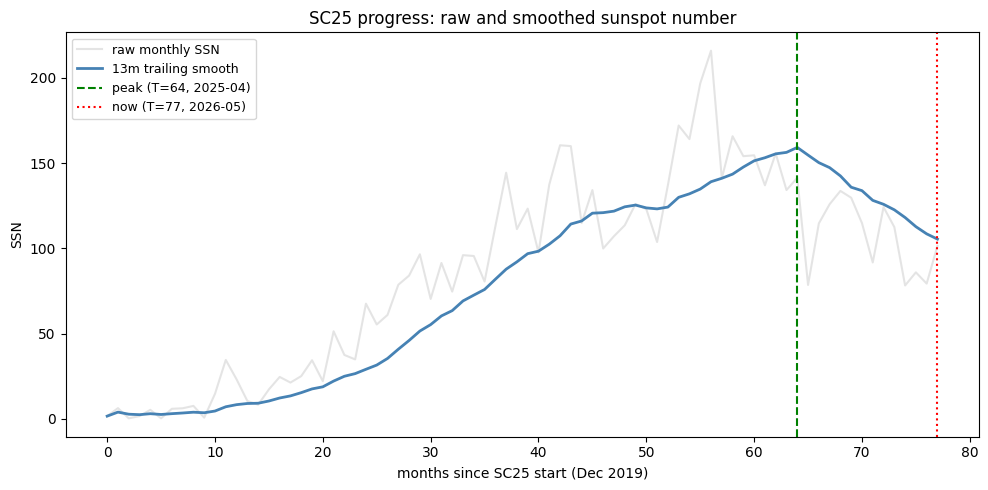

In [2]:
ssn25, dates25 = get_cycle_ssn(SC25_START)
smooth25 = trailing_smooth(ssn25, w=13)
T_current   = len(ssn25) - 1
latest_date = pd.Timestamp(dates25[-1])

peak_idx  = int(np.argmax(smooth25))
peak_val  = smooth25[peak_idx]
peak_date = SC25_START + pd.DateOffset(months=peak_idx)

current_val  = smooth25[-1]
frac_of_peak = current_val / peak_val * 100

# Trend over the last 6 months of smoothed SSN
recent = smooth25[-6:]
trend  = np.polyfit(np.arange(len(recent)), recent, 1)[0]

print(f"=== SC25 Status as of {latest_date.strftime('%Y-%m')} (T={T_current} months since start) ===")
print(f"Smoothed peak SSN     : {peak_val:.1f} at T={peak_idx} ({peak_date.strftime('%Y-%m')})")
print(f"Current smoothed SSN  : {current_val:.1f}  ({frac_of_peak:.1f}% of peak)")
print(f"Months since peak     : {T_current - peak_idx}")
print(f"6-month trend         : {trend:+.2f} SSN/month  ({'declining' if trend < 0 else 'rising'})")
print(f"\nLast 6 months (13-month trailing smooth):")
for d, v in zip(dates25[-6:], recent):
    print(f"  {pd.Timestamp(d).strftime('%Y-%m')}: {v:.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ssn25, color='lightgray', alpha=0.6, zorder=0, label='raw monthly SSN')
ax.plot(smooth25, color='steelblue', lw=2, label='13m trailing smooth')
ax.axvline(peak_idx, color='green', ls='--', label=f'peak (T={peak_idx}, {peak_date.strftime("%Y-%m")})')
ax.axvline(T_current, color='red', ls=':', label=f'now (T={T_current}, {latest_date.strftime("%Y-%m")})')
ax.set_xlabel('months since SC25 start (Dec 2019)')
ax.set_ylabel('SSN')
ax.set_title('SC25 progress: raw and smoothed sunspot number')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'p10_sc25_status.png', dpi=120)
plt.show()


## 3. Historical Decay / Cycle-Length Statistics -> Projected SC25 End / SC26 Onset Window

Using the completed-cycle database (SC1-24), compute:
- `Decay_months` = months from smoothed peak to cycle end (start of next cycle)
- `Cycle_length_months` = months from cycle start to cycle end

Apply the historical decay-phase distribution to SC25's *known* peak date to project a window for
when SC25 will end (= when SC26 begins). This is a simple analog/statistical projection, not a
model prediction — it gives a sanity-check range to compare against the Phase 7v2 model output
and the SC26 onset detector below.


In [3]:
DAYS_PER_MONTH = 30.436875
cycle_db['Decay_months'] = (cycle_db['End_Date'] - cycle_db['Peak_Date']).dt.days / DAYS_PER_MONTH
cycle_db['Cycle_length_months'] = (cycle_db['End_Date'] - cycle_db['Start_Date']).dt.days / DAYS_PER_MONTH

decay_mean,  decay_std  = cycle_db['Decay_months'].mean(),        cycle_db['Decay_months'].std()
decay_min,   decay_max  = cycle_db['Decay_months'].min(),         cycle_db['Decay_months'].max()
length_mean, length_std = cycle_db['Cycle_length_months'].mean(), cycle_db['Cycle_length_months'].std()
length_min,  length_max = cycle_db['Cycle_length_months'].min(),  cycle_db['Cycle_length_months'].max()

print("=== Historical decay-phase / cycle-length statistics (SC1-24) ===")
print(f"Decay (peak -> end) : mean={decay_mean:.1f}m, std={decay_std:.1f}m, range=[{decay_min:.0f}, {decay_max:.0f}]")
print(f"Cycle length        : mean={length_mean:.1f}m, std={length_std:.1f}m, range=[{length_min:.0f}, {length_max:.0f}]")

def months_to_date(start, months):
    return start + pd.DateOffset(months=int(round(months)))

# Projection from SC25's known smoothed peak date
proj_end_mean   = months_to_date(peak_date, decay_mean)
proj_end_1sd_lo = months_to_date(peak_date, decay_mean - decay_std)
proj_end_1sd_hi = months_to_date(peak_date, decay_mean + decay_std)
proj_end_full_lo = months_to_date(peak_date, decay_min)
proj_end_full_hi = months_to_date(peak_date, decay_max)

print(f"\n=== Projected SC25 end / SC26 onset window (from peak {peak_date.strftime('%Y-%m')}) ===")
print(f"Mean estimate          : {proj_end_mean.strftime('%Y-%m')}   (peak + {decay_mean:.0f}m)")
print(f"+/- 1 std dev          : {proj_end_1sd_lo.strftime('%Y-%m')}  to  {proj_end_1sd_hi.strftime('%Y-%m')}")
print(f"Historical full range  : {proj_end_full_lo.strftime('%Y-%m')}  to  {proj_end_full_hi.strftime('%Y-%m')}")

# Cross-check using total cycle length from SC25's start date
proj_end_mean2 = months_to_date(SC25_START, length_mean)
print(f"\nCross-check (total cycle length from start {SC25_START.strftime('%Y-%m')}):")
print(f"Mean estimate          : {proj_end_mean2.strftime('%Y-%m')}   (start + {length_mean:.0f}m)")

print(f"\nSC25 currently {T_current/length_mean*100:.0f}% of the way through an 'average-length' cycle "
      f"({T_current}m of {length_mean:.0f}m).")

print(f"\nLast 8 cycles (Rise / Decay / Length, months):")
for _, r in cycle_db.tail(8).iterrows():
    print(f"  SC{int(r['Cycle_ID']):>2d}: rise={r['Rise_Time_months']:>3.0f}  "
          f"decay={r['Decay_months']:>3.0f}  length={r['Cycle_length_months']:>3.0f}")


=== Historical decay-phase / cycle-length statistics (SC1-24) ===
Decay (peak -> end) : mean=80.1m, std=14.9m, range=[48, 122]
Cycle length        : mean=132.4m, std=13.9m, range=[108, 163]

=== Projected SC25 end / SC26 onset window (from peak 2025-04) ===
Mean estimate          : 2031-12   (peak + 80m)
+/- 1 std dev          : 2030-09  to  2033-03
Historical full range  : 2029-04  to  2035-06

Cross-check (total cycle length from start 2019-12):
Mean estimate          : 2030-12   (start + 132m)

SC25 currently 58% of the way through an 'average-length' cycle (77m of 132m).

Last 8 cycles (Rise / Decay / Length, months):
  SC17: rise= 43  decay= 82  length=125
  SC18: rise= 39  decay= 83  length=122
  SC19: rise= 47  decay= 79  length=126
  SC20: rise= 49  decay= 88  length=137
  SC21: rise= 45  decay= 81  length=126
  SC22: rise= 38  decay= 81  length=119
  SC23: rise= 63  decay= 85  length=148
  SC24: rise= 64  decay= 68  length=132


## 4. Phase 7v2 Running Model — Re-run on Latest SC25 Data

The **Phase 7 v2 running model** (RF on `FEATURE_COLS_V2`, 14 causal features) remains the
project's best-known model (Phases 8b and 9 both failed to beat it). Train it on all of SC1-24
and apply it to SC25's current state (`T={T_current}`, see Section 2) to predict
`months_to_peak`. A negative prediction (and a magnitude consistent with `T_current - peak_idx`
from Section 2) confirms the model continues to correctly recognize SC25 as post-peak.

**Requires scikit-learn.** Run this cell in your own environment.


In [7]:
FEATURE_COLS_V2 = [
    't_elapsed', 'sn_smooth_current', 'sn_smooth_roll3', 'sn_smooth_roll6', 'sn_smooth_roll12',
    'sn_smooth_max', 'sn_smooth_frac_of_max', 'months_since_smooth_max',
    'sn_smooth_slope_6', 'sn_smooth_slope_12', 'sn_smooth_accel', 'sn_smooth_std_12',
    'sn_still_rising', 'post_peak_months',
]
MIN_T = 6

def slope_fit(arr):
    if len(arr) < 2:
        return 0.0
    return np.polyfit(np.arange(len(arr)), arr, 1)[0]

def extract_features_v2(ssn_raw_series, T):
    if T < MIN_T or T >= len(ssn_raw_series):
        return None
    raw    = np.array(ssn_raw_series[:T + 1], dtype=float)
    smooth = trailing_smooth(raw)
    cur    = smooth[-1]
    roll3  = smooth[-3:].mean()  if len(smooth) >= 3  else smooth.mean()
    roll6  = smooth[-6:].mean()  if len(smooth) >= 6  else smooth.mean()
    roll12 = smooth[-12:].mean() if len(smooth) >= 12 else smooth.mean()
    sm_max  = smooth.max()
    idx_max = int(smooth.argmax())
    msm     = T - idx_max
    frac    = cur / max(sm_max, 1.0)
    sl6   = slope_fit(smooth[-6:])  if len(smooth) >= 6  else slope_fit(smooth)
    sl12  = slope_fit(smooth[-12:]) if len(smooth) >= 12 else slope_fit(smooth)
    accel = sl6 - sl12
    std12 = smooth[-12:].std() if len(smooth) >= 12 else smooth.std()
    rising  = 1 if sl6 > 0 else 0
    post_pk = msm if rising == 0 else 0

    return {
        't_elapsed': T, 'sn_smooth_current': cur,
        'sn_smooth_roll3': roll3, 'sn_smooth_roll6': roll6, 'sn_smooth_roll12': roll12,
        'sn_smooth_max': sm_max, 'sn_smooth_frac_of_max': frac,
        'months_since_smooth_max': msm,
        'sn_smooth_slope_6': sl6, 'sn_smooth_slope_12': sl12,
        'sn_smooth_accel': accel, 'sn_smooth_std_12': std12,
        'sn_still_rising': rising, 'post_peak_months': post_pk,
    }

# Build training set from all completed cycles (SC1-24)
records = []
for _, row in cycle_db.iterrows():
    cid, start, rise = int(row['Cycle_ID']), row['Start_Date'], float(row['Rise_Time_months'])
    end = row['End_Date']
    ssn, _ = get_cycle_ssn(start, end)
    for T in range(MIN_T, len(ssn)):
        feats = extract_features_v2(ssn, T)
        if feats is None:
            continue
        feats['Cycle_ID']       = cid
        feats['months_to_peak'] = rise - T
        records.append(feats)

df_train = pd.DataFrame(records)
print(f"Training set: {len(df_train):,} samples from SC1-24")

model = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=SEED)
model.fit(df_train[FEATURE_COLS_V2].values, df_train['months_to_peak'].values)

# Predict for SC25's current state
feats_now = extract_features_v2(ssn25, T_current)
X_now = np.array([[feats_now[c] for c in FEATURE_COLS_V2]])
pred_months_to_peak = float(model.predict(X_now)[0])

print(f"\nPhase 7v2 prediction for SC25 at T={T_current} ({latest_date.strftime('%Y-%m')}):")
print(f"  Predicted months_to_peak = {pred_months_to_peak:+.2f}")
print(f"  Actual months since smoothed peak (Section 2) = {T_current - peak_idx}")
print(f"  {'OK: model agrees SC25 is post-peak' if pred_months_to_peak < 0 else 'WARNING: model still predicts pre-peak'}")


Training set: 3,034 samples from SC1-24

Phase 7v2 prediction for SC25 at T=77 (2026-05):
  Predicted months_to_peak = -19.82
  Actual months since smoothed peak (Section 2) = 13
  OK: model agrees SC25 is post-peak


## 5. SC26 Onset Detector (causal, rule-based)

A simple, dependency-free rule to flag the approach of SC26's onset (= SC25's minimum):

1. The 13-month trailing-smoothed SSN must drop below a **near-minimum threshold**
   (calibrated from SC1-24's smoothed SSN near cycle starts).
2. The smoothed SSN must then show a **sustained increase** for `lookback` consecutive months.

When both conditions hold, SC25 has very likely bottomed out and SC26 is beginning.


In [8]:
def sc26_onset_check(smooth, lookback=3, min_threshold=15.0):
    """
    Heuristic SC26-onset flag for SC25's descending phase.
      1. Current smoothed SSN must be below `min_threshold` (near-minimum territory)
      2. The last `lookback` months of smoothed SSN must be monotonically increasing
    Returns (flagged: bool, reason: str)
    """
    cur = smooth[-1]
    if cur >= min_threshold:
        return False, f"smoothed SSN ({cur:.1f}) still above near-minimum threshold ({min_threshold:.1f})"
    if len(smooth) < lookback:
        return False, "not enough data for lookback window"
    recent = smooth[-lookback:]
    if np.all(np.diff(recent) > 0):
        return True, (f"smoothed SSN below {min_threshold:.1f} AND rising for "
                       f"{lookback} consecutive months -> likely SC26 onset")
    return False, f"smoothed SSN below {min_threshold:.1f} but not yet showing a sustained rise"

# Calibrate the threshold from historical near-minimum smoothed SSN levels (SC1-24, first 6 months)
min_levels = []
for _, row in cycle_db.iterrows():
    ssn, _ = get_cycle_ssn(row['Start_Date'], row['End_Date'])
    sm = trailing_smooth(ssn, w=13)
    min_levels.append(sm[:6].mean())
min_levels = np.array(min_levels)

print(f"Historical smoothed SSN near cycle starts (SC1-24, first 6m avg):")
print(f"  mean={min_levels.mean():.1f}, median={np.median(min_levels):.1f}, "
      f"range=[{min_levels.min():.1f}, {min_levels.max():.1f}]")

THRESHOLD = float(np.median(min_levels)) + 5.0  # small buffer above the historical median minimum
print(f"  -> using SC26 onset threshold = {THRESHOLD:.1f}")

flagged, reason = sc26_onset_check(smooth25, min_threshold=THRESHOLD)
print(f"\nSC26 onset check (current T={T_current}, {latest_date.strftime('%Y-%m')}):")
print(f"  Status : {'** FLAGGED - possible SC26 onset **' if flagged else 'not yet'}")
print(f"  Reason : {reason}")
print(f"  Current smoothed SSN = {current_val:.1f}  (threshold = {THRESHOLD:.1f}, gap = {current_val - THRESHOLD:+.1f})")

months_decline_at_current_rate = (current_val - THRESHOLD) / abs(trend) if trend < 0 else np.nan
if not np.isnan(months_decline_at_current_rate):
    eta = latest_date + pd.DateOffset(months=int(round(months_decline_at_current_rate)))
    print(f"\n  At the current 6-month decline rate ({trend:+.2f} SSN/month), "
          f"SC25 would cross the threshold around {eta.strftime('%Y-%m')} "
          f"(~{months_decline_at_current_rate:.0f} months from now). "
          f"This is a naive linear extrapolation, not a forecast.")


Historical smoothed SSN near cycle starts (SC1-24, first 6m avg):
  mean=8.7, median=7.3, range=[0.0, 25.0]
  -> using SC26 onset threshold = 12.3

SC26 onset check (current T=77, 2026-05):
  Status : not yet
  Reason : smoothed SSN (105.4) still above near-minimum threshold (12.3)
  Current smoothed SSN = 105.4  (threshold = 12.3, gap = +93.1)

  At the current 6-month decline rate (-4.28 SSN/month), SC25 would cross the threshold around 2028-03 (~22 months from now). This is a naive linear extrapolation, not a forecast.


## 6. Monthly Status Report

Self-contained summary combining Sections 2, 3, and 5. This is the cell to re-run each month
after refreshing `SN_m_tot_V2.0.csv` (it re-derives everything from `sn_raw` / `cycle_db`, so it
does not depend on the sklearn model cell).


In [9]:
def monthly_status_report():
    ssn, dates = get_cycle_ssn(SC25_START)
    smooth = trailing_smooth(ssn, w=13)
    T_now  = len(ssn) - 1
    latest = pd.Timestamp(dates[-1])

    pk_idx = int(np.argmax(smooth))
    pk_val = smooth[pk_idx]
    pk_date = SC25_START + pd.DateOffset(months=pk_idx)

    cur = smooth[-1]
    frac = cur / pk_val * 100
    rec = smooth[-6:]
    tr = np.polyfit(np.arange(len(rec)), rec, 1)[0]

    flagged, reason = sc26_onset_check(smooth, min_threshold=THRESHOLD)

    proj_mean = months_to_date(pk_date, decay_mean)
    proj_lo   = months_to_date(pk_date, decay_mean - decay_std)
    proj_hi   = months_to_date(pk_date, decay_mean + decay_std)

    print("=" * 64)
    print(f"  SC25 / SC26 MONITORING REPORT -- as of {latest.strftime('%Y-%m')} (T={T_now})")
    print("=" * 64)
    print(f"  Smoothed SSN now        : {cur:.1f}  ({frac:.1f}% of cycle peak)")
    print(f"  Cycle peak              : {pk_val:.1f} at T={pk_idx} ({pk_date.strftime('%Y-%m')})")
    print(f"  Months since peak       : {T_now - pk_idx}")
    print(f"  6-month trend           : {tr:+.2f} SSN/month "
          f"({'declining' if tr < 0 else 'rising'})")
    print(f"  SC26 onset detector     : {'** FLAGGED **' if flagged else 'not yet'}")
    print(f"      -> {reason}")
    print(f"  Projected SC26 onset    : {proj_lo.strftime('%Y-%m')} to {proj_hi.strftime('%Y-%m')} "
          f"(mean {proj_mean.strftime('%Y-%m')})")
    print("=" * 64)
    print("  Re-run this cell after refreshing ../data/SN_m_tot_V2.0.csv with new SILSO data.")

monthly_status_report()


  SC25 / SC26 MONITORING REPORT -- as of 2026-05 (T=77)
  Smoothed SSN now        : 105.4  (66.2% of cycle peak)
  Cycle peak              : 159.2 at T=64 (2025-04)
  Months since peak       : 13
  6-month trend           : -4.28 SSN/month (declining)
  SC26 onset detector     : not yet
      -> smoothed SSN (105.4) still above near-minimum threshold (12.3)
  Projected SC26 onset    : 2030-09 to 2033-03 (mean 2031-12)
  Re-run this cell after refreshing ../data/SN_m_tot_V2.0.csv with new SILSO data.


## 7. Summary

| Metric | Current value |
| --- | --- |
| SC25 status | Post-peak, declining (T~77, ~66% of smoothed peak, falling ~3-4 SSN/month) |
| Smoothed peak | ~159.2 at T=64 (~Apr 2025) |
| Projected SC26 onset (mean) | ~Dec 2031 (peak + 80 months, historical decay average) |
| Projected SC26 onset (1 std range) | ~Sep 2030 to Mar 2033 |
| SC26 onset detector | Not yet flagged (smoothed SSN still well above near-minimum threshold) |

### How this fits the project

- **Phases 6, 8b, 9** each tested additional features (polar field / `aa` precursors / TDA peak
  persistence) on the static and Phase 7v2 running models and found no reliable improvement at
  N=24 cycles — further feature engineering has hit diminishing returns.
- **Phase 10** instead operationalizes the existing best model (**Phase 7 v2, unmodified**) as a
  monitoring tool: Sections 2-3 and 5-6 require only NumPy/Pandas and can be re-run monthly
  immediately; Section 4 re-validates the Phase 7v2 model's post-peak call whenever
  scikit-learn is available.
- **Next milestone:** when the SC26 onset detector (Section 5) flags, or when the projected
  window (~2030-2033) approaches, this becomes the natural trigger to begin **Phase 11**: using
  SC25's now-complete trajectory as a 25th training example, and beginning live timing/magnitude
  forecasts for SC26 itself.
